# 2D Kelvin Helmholtz Instability

## Imports

In [1]:
# ==== GPU selection ====
from autocvd import autocvd
autocvd(num_gpus = 1)
# ruff: noqa: E402
# =======================

# general
import jax.numpy as jnp

# astronomix constants
from astronomix import (
    PERIODIC_BOUNDARY,
)

# astronomix containers
from astronomix import (
    SimulationConfig,
    SimulationParams,
    BoundarySettings,
    BoundarySettings1D,
    SnapshotSettings,
)

# astronomix functions
from astronomix import (
    get_helper_data,
    time_integration,
    construct_primitive_state,
    get_registered_variables,
    finalize_config
)

# plotting
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import LogNorm
from IPython.display import Image

## Initiating the Kelvin Helmholtz Instability

In [2]:
gamma = 5/3

# spatial domain
box_size = 1.0
num_cells = 512

fixed_timestep = False
scale_time = False
dt_max = 0.1
num_timesteps = 2000

config = SimulationConfig(
    progress_bar = True,
    dimensionality = 2,
    box_size = box_size, 
    num_cells = num_cells,
    fixed_timestep = fixed_timestep,
    num_timesteps = num_timesteps,
    boundary_settings = BoundarySettings(
        x = BoundarySettings1D(PERIODIC_BOUNDARY, PERIODIC_BOUNDARY),
        y = BoundarySettings1D(PERIODIC_BOUNDARY, PERIODIC_BOUNDARY)
    ),
    return_snapshots = True,
    num_snapshots = 100,
    snapshot_settings = SnapshotSettings(
        return_states = True,
    )
)

helper_data = get_helper_data(config)

params = SimulationParams(
    t_end = 2.0,
    C_cfl = 0.4
)

registered_variables = get_registered_variables(config)

## Setting the initial state

In [3]:
num_cells = config.num_cells
x = jnp.linspace(0, 1, num_cells)
y = jnp.linspace(0, 1, num_cells)
X, Y = jnp.meshgrid(x, y, indexing="ij")

rho = jnp.ones_like(X)
u_x = 0.5 * jnp.ones_like(X)
u_y = 0.01 * jnp.sin(2 * jnp.pi * X)

mask = (Y > 0.25) & (Y < 0.75)
u_x = jnp.where(mask, -0.5, u_x)
rho = jnp.where(mask, 2.0, rho)

p = jnp.ones((num_cells, num_cells)) * 2.5

# initial state
initial_state = construct_primitive_state(
    config = config,
    registered_variables = registered_variables,
    density = rho,
    velocity_x = u_x,
    velocity_y = u_y,
    gas_pressure = p
)
config = finalize_config(config, initial_state.shape)

OPTIMAL_BACKEND: using the PALLAS backend (GPU compute capability >= 8.0).
For 2D simulations with periodic boundaries, setting boundary handling to PERIODIC_ROLL and num_ghost_cells to 0 for better performance.
Setting time integrator to RK4_SSP for finite difference solver mode.


## Simulation

In [4]:
result = time_integration(initial_state, config, params, registered_variables)

 |████████████████████████████████████████████████████████████████████| 100.0%  


## Visualization

### Cut

Text(0.5, 1.0, 'Pressure')

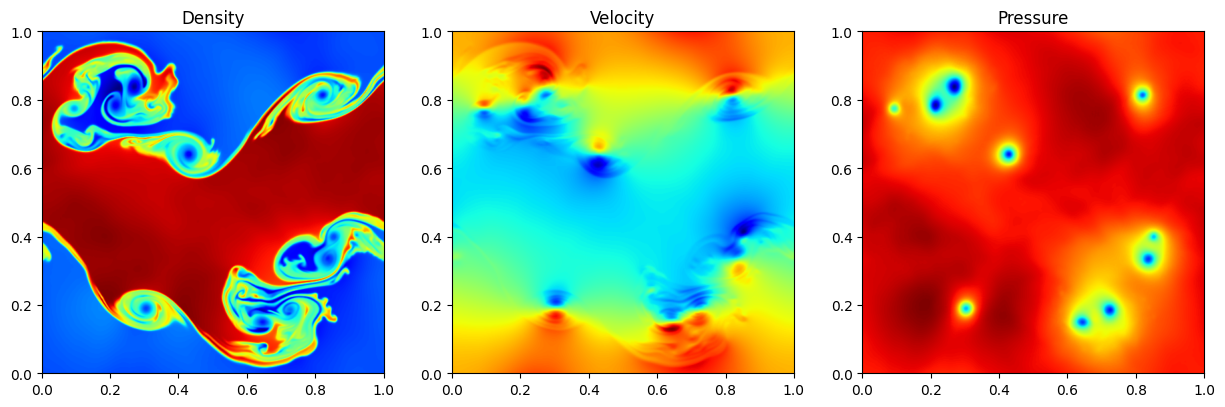

In [5]:
final_state = result.states[-1]

s = 0.1

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.set_aspect('equal', 'box')
ax2.set_aspect('equal', 'box')
ax3.set_aspect('equal', 'box')

x = jnp.linspace(0, box_size, num_cells)
y = jnp.linspace(0, box_size, num_cells)

ym, xm = jnp.meshgrid(x, y)

norm_rho = LogNorm(vmin = jnp.min(final_state[0, :, :]), vmax = jnp.max(final_state[0, :, :]), clip = True)
norm_p = LogNorm(vmin = jnp.min(final_state[3, :, :]), vmax = jnp.max(final_state[3, :, :]), clip = True)

ax1.imshow(final_state[0, :, :].T, norm = norm_rho, cmap = "jet", origin = "lower", extent = [0, box_size, 0, box_size])
ax1.set_title("Density")

ax2.imshow(final_state[1, :, :].T, cmap = "jet", origin = "lower", extent = [0, box_size, 0, box_size])
ax2.set_title("Velocity")

ax3.imshow(final_state[4, :, :].T, norm = norm_p, cmap = "jet", origin = "lower", extent = [0, box_size, 0, box_size])
ax3.set_title("Pressure")

## Animation

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal', 'box')

density = result.states[0][0, :, :]
norm = LogNorm(vmin=jnp.min(density), vmax=jnp.max(density), clip=True)
im = ax.imshow(density.T, norm=norm, cmap="jet", origin="lower", extent=[0, box_size, 0, box_size])
ax.set_title("Density")

def update(frame):
    density = result.states[frame][0, :, :]
    im.set_data(density.T)
    return [im]

ani = animation.FuncAnimation(fig, update, frames=len(result.states), blit=True)

ani.save("kelvin_helmholtz.gif", fps=24)

plt.close(fig)

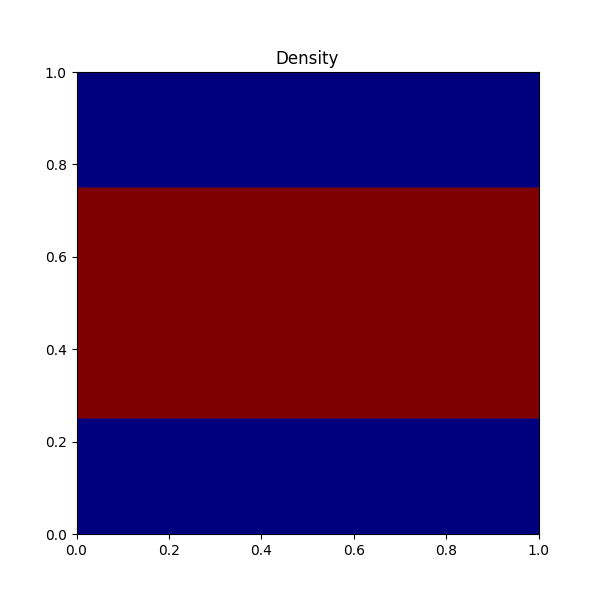

In [7]:
Image(filename='kelvin_helmholtz.gif')